In [1]:
import pandas as pd
import numpy as np

Stage 1: Data Ingestion
Objective
Load datasets into Pandas DataFrames.

Dataset: https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020

Tasks
Read both CSV files
Inspect:
shape
columns
data types
Expected Output
Two DataFrames:
deliveries_df
matches_df

In [2]:
deliveries_df=pd.read_csv('deliveries.csv')
matches_df=pd.read_csv('matches.csv')


In [3]:
print(deliveries_df)

        match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

        over  ball       batter        

In [4]:
print(matches_df)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

                                       

Stage 2: Data Cleaning & Validation
Objective
Ensure data quality before analysis.

Tasks:

Check for missing values
Handle or report inconsistencies

Validate: match IDs alignment between datasets
correct data types (numeric vs categorical)

Deliverables
Cleaned DataFrames ready for processing

In [5]:
deliveries_df.dropna(axis=0)  # Drops rows with any null values
print(deliveries_df)

        match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

        over  ball       batter        

In [6]:
deliveries_df.isnull().sum()  # Returns total null values in the deliveries_df

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [7]:
matches_df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [8]:
print(matches_df[matches_df["winner"].isnull()])

          id season       city        date match_type player_of_match  \
241   501265   2011      Delhi  2011-05-21     League             NaN   
485   829763   2015  Bangalore  2015-04-29     League             NaN   
511   829813   2015  Bangalore  2015-05-17     League             NaN   
744  1178424   2019  Bengaluru  2019-04-30     League             NaN   
994  1359519   2023    Lucknow  2023-05-03     League             NaN   

                                                 venue  \
241                                   Feroz Shah Kotla   
485                              M Chinnaswamy Stadium   
511                              M Chinnaswamy Stadium   
744                              M.Chinnaswamy Stadium   
994  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...   

                           team1                team2  \
241             Delhi Daredevils        Pune Warriors   
485  Royal Challengers Bangalore     Rajasthan Royals   
511  Royal Challengers Bangalore     Delh

In [9]:
matches_df = matches_df.dropna(subset=["winner"])
print(matches_df)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

                                       

In [10]:
print(matches_df[matches_df["city"].isnull()])

          id   season city        date   match_type player_of_match  \
399   729281     2014  NaN  2014-04-17       League       YS Chahal   
402   729287     2014  NaN  2014-04-19       League        PA Patel   
403   729289     2014  NaN  2014-04-19       League       JP Duminy   
404   729291     2014  NaN  2014-04-20       League      GJ Maxwell   
406   729295     2014  NaN  2014-04-22       League      GJ Maxwell   
407   729297     2014  NaN  2014-04-23       League       RA Jadeja   
408   729299     2014  NaN  2014-04-24       League         CA Lynn   
409   729301     2014  NaN  2014-04-25       League        AJ Finch   
410   729303     2014  NaN  2014-04-25       League       MM Sharma   
413   729309     2014  NaN  2014-04-27       League         M Vijay   
414   729311     2014  NaN  2014-04-27       League        DR Smith   
415   729313     2014  NaN  2014-04-28       League  Sandeep Sharma   
417   729317     2014  NaN  2014-04-30       League         B Kumar   
757  1

In [11]:
venue_to_city = {   'Dubai International Cricket Stadium': 'Dubai',
                    'Sharjah Cricket Stadium': 'Sharjah',
                    'Sheikh Zayed Stadium': 'Abu Dhabi',
                    'Zayed Cricket Stadium': 'Abu Dhabi'}
for venue, city in venue_to_city.items():
    matches_df.loc[(matches_df['city'].isnull()) & (matches_df['venue'].str.contains(venue)), 'city'] = city
print(f"Missing cities after cleaning: {matches_df['city'].isnull().sum()}")

Missing cities after cleaning: 0


In [12]:
print(matches_df)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

                                       

In [13]:
matches_df.isnull().sum()

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64

Stage 3: Data Transformation

Objective:
Prepare data for analysis.

Tasks:
Create new columns:
Total runs per ball (if extras exist, include logic)
Standardize columns:
Ensure consistent naming
Merge datasets:
deliveries_df.merge(matches_df, left_on="match_id", right_on="id")

Output:
A unified DataFrame for analysis

In [22]:
matches_df = matches_df.rename(columns={'id': 'match_id'})
unified_df = pd.merge(deliveries_df, matches_df, on="match_id", how="left")

unified_df['total_runs_per_ball'] = unified_df['batsman_runs'] + unified_df['extra_runs']

1. Total Runs per Match
Calculate total runs scored in each match.

In [23]:
match_runs_summary = (
    unified_df.groupby('match_id')['total_runs_per_ball'] 
    .sum()
    .reset_index()
    .rename(columns={'total_runs_per_ball': 'match_total_runs'})
)
print(match_runs_summary)

      match_id  match_total_runs
0       335982               304
1       335983               447
2       335984               261
3       335985               331
4       335986               222
...        ...               ...
1090   1426307               429
1091   1426309               323
1092   1426310               346
1093   1426311               314
1094   1426312               227

[1095 rows x 2 columns]


2. Runs per Team per Match
Compute total runs scored by each team in every match.

In [24]:
team_match_runs = (
    unified_df.groupby(['match_id', 'batting_team'])['total_runs_per_ball']
    .sum()
    .reset_index()
    .rename(columns={'total_runs_per_ball': 'team_total_runs'})
)
team_match_runs = team_match_runs.sort_values(by='match_id')
print(team_match_runs.head())

   match_id                 batting_team  team_total_runs
0    335982        Kolkata Knight Riders              222
1    335982  Royal Challengers Bangalore               82
2    335983          Chennai Super Kings              240
3    335983              Kings XI Punjab              207
4    335984             Delhi Daredevils              132


3. Top 10 Batters
Identify top 10 batters based on total runs scored.

In [25]:

top_10_batters = (
    unified_df.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_10_batters)

           batter  batsman_runs
0         V Kohli          8014
1        S Dhawan          6769
2       RG Sharma          6630
3       DA Warner          6567
4        SK Raina          5536
5        MS Dhoni          5243
6  AB de Villiers          5181
7        CH Gayle          4997
8      RV Uthappa          4954
9      KD Karthik          4843


4. Strike Rate of Batters
Calculate strike rate for each batter:

Runs scored

Balls faced

In [26]:

batter_stats = (
    unified_df.groupby('batter')
    .agg({'batsman_runs': 'sum', 'ball': 'count'})
    .rename(columns={'batsman_runs': 'total_runs', 'ball': 'balls_faced'})
)

batter_stats['strike_rate'] = (batter_stats['total_runs'] / batter_stats['balls_faced']) * 100
top_sr = batter_stats[batter_stats['balls_faced'] >= 50].sort_values(by='strike_rate', ascending=False).head(10)
print(top_sr)

                 total_runs  balls_faced  strike_rate
batter                                               
J Fraser-McGurk         330          150   220.000000
WG Jacks                230          133   172.932331
PD Salt                 653          385   169.610390
T Stubbs                405          239   169.456067
R Shepherd              115           68   169.117647
TM Head                 772          458   168.558952
LJ Wright               106           63   168.253968
Naman Dhir              140           84   166.666667
KK Cooper               116           70   165.714286
AD Russell             2488         1515   164.224422


5. Top 10 Bowlers by Economy
Calculate economy rate and rank bowlers.

In [27]:

bowler_stats = (
    unified_df.groupby('bowler')
    .agg({'total_runs_per_ball': 'sum', 'ball': 'count'})
    .rename(columns={'total_runs_per_ball': 'runs_conceded', 'ball': 'balls_bowled'})
)

bowler_stats['economy'] = bowler_stats['runs_conceded'] / (bowler_stats['balls_bowled'] / 6)

top_economy = (
    bowler_stats[bowler_stats['balls_bowled'] >= 120]
    .sort_values(by='economy', ascending=True)
    .head(10)
)
print(top_economy)

                 runs_conceded  balls_bowled   economy
bowler                                                
Sohail Tanvir              275           265  6.226415
A Chandila                 245           234  6.282051
FH Edwards                 160           150  6.400000
SMSM Senanayake            211           195  6.492308
SM Pollock                 307           280  6.578571
A Kumble                  1089           983  6.646999
GD McGrath                 366           329  6.674772
M Muralitharan            1765          1581  6.698292
IS Sodhi                   204           182  6.725275
J Yadav                    447           398  6.738693


6. Most Consistent Batters
Find batters with:

High average runs per match
Minimum number of matches played

In [28]:
runs_per_match = unified_df.groupby(['batter', 'match_id'])['batsman_runs'].sum().reset_index()

consistency_stats = (
    runs_per_match.groupby('batter')['batsman_runs']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'average_runs', 'count': 'matches_played'})
)

consistent_batters = (
    consistency_stats[consistency_stats['matches_played'] >= 20]
    .sort_values(by='average_runs', ascending=False)
    .head(10)
)
print(consistent_batters)

                 average_runs  matches_played
batter                                       
DP Conway           42.000000              22
B Sai Sudharsan     41.360000              25
KL Rahul            38.434426             122
LMP Simmons         37.206897              29
RD Gaikwad          36.615385              65
SE Marsh            36.072464              69
DA Warner           35.690217             184
CH Gayle            35.439716             141
ML Hayden           34.593750              32
MEK Hussey          34.086207              58


7. Highest Individual Score in a Match
Find the highest runs scored by a batter in a single match.

In [29]:

highest_individual_score = (
    unified_df.groupby(['match_id', 'batter'])['batsman_runs']
    .sum()
    .max()
)

print(f"The highest individual score in a match is: {highest_individual_score}")

The highest individual score in a match is: 175


8. Boundary Analysis
Total number of 4s and 6s
Top players by boundaries

In [30]:

total_fours = unified_df[unified_df['batsman_runs'] == 4].shape[0]
total_sixes = unified_df[unified_df['batsman_runs'] == 6].shape[0]

boundary_players = (
    unified_df[unified_df['batsman_runs'].isin([4, 6])]
    .groupby('batter')['batsman_runs']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'batsman_runs': 'total_boundaries'})
)

print(f"Total 4s: {total_fours}, Total 6s: {total_sixes}")
print(boundary_players)

Total 4s: 29850, Total 6s: 13051
           batter  total_boundaries
0         V Kohli               981
1        S Dhawan               921
2       DA Warner               899
3       RG Sharma               880
4        CH Gayle               767
5        SK Raina               710
6  AB de Villiers               667
7      RV Uthappa               663
8      KD Karthik               627
9        MS Dhoni               615


9. Boundary Percentage
For each batter:

Percentage of runs coming from boundaries

In [31]:

total_runs = unified_df.groupby('batter')['batsman_runs'].sum()
boundary_runs = unified_df[unified_df['batsman_runs'].isin([4, 6])].groupby('batter')['batsman_runs'].sum()

boundary_dist = pd.DataFrame({'total_runs': total_runs, 'boundary_runs': boundary_runs}).fillna(0)
boundary_dist['boundary_percentage'] = (boundary_dist['boundary_runs'] / boundary_dist['total_runs']) * 100

top_boundary_hitters = boundary_dist[boundary_dist['total_runs'] >= 200].sort_values(by='boundary_percentage', ascending=False).head(10)
print(top_boundary_hitters)

                 total_runs  boundary_runs  boundary_percentage
batter                                                         
J Fraser-McGurk         330          296.0            89.696970
SP Narine              1534         1238.0            80.704042
AD Russell             2488         1938.0            77.893891
MJ Lumb                 278          216.0            77.697842
PD Salt                 653          500.0            76.569678
CH Gayle               4997         3786.0            75.765459
KR Mayers               379          284.0            74.934037
WG Jacks                230          172.0            74.782609
ST Jayasuriya           768          570.0            74.218750
P Simran Singh          756          558.0            73.809524


10. Dot Ball Analysis
Count dot balls (runs == 0)
Identify bowlers with most dot balls

In [32]:

dot_ball_counts = (
    unified_df[unified_df['total_runs_per_ball'] == 0]
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={0: 'dot_balls'})
)

print(dot_ball_counts)

            bowler  dot_balls
0          B Kumar       1632
1        SP Narine       1569
2         R Ashwin       1552
3        PP Chawla       1325
4  Harbhajan Singh       1263
5        JJ Bumrah       1228
6        RA Jadeja       1216
7        YS Chahal       1194
8         UT Yadav       1186
9         A Mishra       1185


11. Runs per Over Analysis
Average runs scored in each over (1–20)
Identify high-scoring overs

In [33]:

runs_per_over = (
    unified_df.groupby('over')['total_runs_per_ball']
    .mean()
    .reset_index()
    .rename(columns={'total_runs_per_ball': 'avg_runs_per_over'})
)
high_scoring_overs = runs_per_over.sort_values(by='avg_runs_per_over', ascending=False)
print(high_scoring_overs)

    over  avg_runs_per_over
19    19           1.776855
18    18           1.646896
17    17           1.587839
16    16           1.498778
15    15           1.434273
14    14           1.393504
5      5           1.373055
4      4           1.369100
3      3           1.356538
13    13           1.343645
2      2           1.316099
12    12           1.301240
11    11           1.287686
10    10           1.262623
8      8           1.242087
9      9           1.224577
7      7           1.189948
1      1           1.173528
6      6           1.103107
0      0           0.981663


12. Powerplay Performance (Overs 1–6)
Total runs in powerplay
Best teams in powerplay

In [ ]:
pp_df = unified_df[unified_df['over'] <= 6]
pp_team_performance = pp_df.groupby('batting_team')['total_runs_per_ball'].sum().sort_values(ascending=False)
print(pp_team_performance)

batting_team
Mumbai Indians                 13943
Kolkata Knight Riders          13632
Chennai Super Kings            12631
Royal Challengers Bangalore    12429
Rajasthan Royals               11774
Kings XI Punjab                10295
Sunrisers Hyderabad            10170
Delhi Daredevils                8503
Delhi Capitals                  5358
Deccan Chargers                 3889
Punjab Kings                    3231
Gujarat Titans                  2504
Lucknow Super Giants            2355
Pune Warriors                   2141
Gujarat Lions                   1818
Royal Challengers Bengaluru      993
Rising Pune Supergiant           877
Kochi Tuskers Kerala             769
Rising Pune Supergiants          744
Name: total_runs_per_ball, dtype: int64


13. Death Overs Performance (Overs 16–20)
Total runs
Best teams and batters in death overs

In [36]:
death_df = unified_df[unified_df['over'] >= 16]
death_batter_performance = death_df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print(death_batter_performance)

batter
MS Dhoni          2786
KA Pollard        1708
KD Karthik        1565
AB de Villiers    1421
RA Jadeja         1420
RG Sharma         1176
HH Pandya         1126
V Kohli           1099
AD Russell        1065
DA Miller          988
Name: batsman_runs, dtype: int64


14. Run Distribution per Inning
Compare:

First inning vs second inning scoring patterns

In [37]:

inning_patterns = unified_df.groupby('inning')['total_runs_per_ball'].mean().reset_index()
print(inning_patterns)

   inning  total_runs_per_ball
0       1             1.342591
1       2             1.321733
2       3             1.779221
3       4             1.708333
4       5             1.375000
5       6             3.750000


1 AND 2 ARE THE FIRST TWO INNINGS IN AN OVER

3 AND 4 ARE THE INNINGS IN THE SUPER OVER OF A GAME

5 AND 6 ARE THE INNINGS IN THE SUPER OVER OF A GAME


15. Toss Impact Analysis
Compare runs scored by toss-winning team vs opponent
Analyze if toss gives advantage

In [38]:

match_level_df = unified_df.drop_duplicates('match_id') #dropping dulplicate data so that there is only one entry for each match rather than delivery based data

toss_win_match_win_pct = (match_level_df['toss_winner'] == match_level_df['winner']).mean() * 100
print(toss_win_match_win_pct)

50.593607305936075


16. Player of Match Contribution
Check:

Did the player of the match contribute the highest runs?

In [ ]:
#finding the top run-scorer for each match
match_batters = (
    unified_df.groupby(['match_id', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)
#sorting and keeping the top scorer per match
top_scorers = (
    match_batters.sort_values(['match_id', 'batsman_runs'], ascending=[True, False])
    .drop_duplicates('match_id')
)
pom_column = 'player_of_match' 
pom_data = unified_df[['match_id', pom_column]].drop_duplicates()

pom_analysis = pd.merge(top_scorers, pom_data, on='match_id')
#compare batter name with player_of_match
pom_analysis['is_top_scorer_pom'] = pom_analysis['batter'] == pom_analysis[pom_column]

#calculating percentage
contribution_pct = pom_analysis['is_top_scorer_pom'].mean() * 100

print(f"Percentage of matches where top scorer won Player of the match: {contribution_pct:.2f}%")

Percentage of matches where top scorer won PoM: 45.30%


17. Venue-wise Analysis
Total matches per venue
Average runs scored at each venue


In [49]:
venue_stats = (
    unified_df.groupby('venue')
    .agg({'match_id': 'nunique', 'total_runs_per_ball': 'sum'})
    .rename(columns={'match_id': 'total_matches', 'total_runs_per_ball': 'total_runs'})
)

venue_stats['avg_runs_per_match'] = venue_stats['total_runs'] / venue_stats['total_matches']
print(venue_stats.sort_values(by='total_matches', ascending=False).head(10))

                                            total_matches  total_runs  \
venue                                                                   
Eden Gardens                                           77       23658   
Wankhede Stadium                                       73       23407   
M Chinnaswamy Stadium                                  63       19874   
Feroz Shah Kotla                                       59       18365   
Rajiv Gandhi International Stadium, Uppal              49       14888   
MA Chidambaram Stadium, Chepauk                        48       15277   
Sawai Mansingh Stadium                                 47       14264   
Dubai International Cricket Stadium                    46       14450   
Wankhede Stadium, Mumbai                               45       15587   
Punjab Cricket Association Stadium, Mohali             35       10987   

                                            avg_runs_per_match  
venue                                                     

18. City-wise Scoring Trends
Average runs by city
Identify high-scoring cities

In [42]:
city_stats = (
    unified_df.groupby('city')
    .agg({'match_id': 'nunique', 'total_runs_per_ball': 'sum'})
    .rename(columns={'match_id': 'total_matches', 'total_runs_per_ball': 'total_runs'})
)

city_stats['avg_runs_by_city'] = city_stats['total_runs'] / city_stats['total_matches']

print(city_stats.sort_values(by='avg_runs_by_city', ascending=False).head(10))

            total_matches  total_runs  avg_runs_by_city
city                                                   
Bengaluru              28       10346        369.500000
Guwahati                3        1019        339.666667
Dharamsala             13        4412        339.384615
Mohali                  5        1675        335.000000
Rajkot                 10        3333        333.300000
Ahmedabad              36       11917        331.027778
Mumbai                173       56817        328.421965
Delhi                  89       28999        325.831461
Chandigarh             61       19864        325.639344
Cuttack                 7        2278        325.428571


19. Season-wise Run Trends
Total runs per season
Growth or decline trends

In [43]:
season_trends = (
    unified_df.groupby('season')['total_runs_per_ball']
    .sum()
    .reset_index()
    .rename(columns={'total_runs_per_ball': 'total_season_runs'})
)

print(season_trends.sort_values(by='season'))

     season  total_season_runs
0   2007/08              17937
1      2009              16353
2   2009/10              18883
3      2011              21098
4      2012              22453
5      2013              22602
6      2014              18931
7      2015              17964
8      2016              18862
9      2017              18786
10     2018              19901
11     2019              19331
12  2020/21              19416
13     2021              18637
14     2022              24395
15     2023              25563
16     2024              25971


20. Winning Team Analysis
Determine winner based on runs
Compare with actual outcomes (if available)

In [ ]:

calculated_winners=(
    team_match_runs.sort_values(['match_id', 'team_total_runs'], ascending=[True, False])
    .drop_duplicates('match_id')
    .rename(columns={'batting_team': 'calculated_winner', 'team_total_runs': 'winning_score'})
)

comparison=pd.merge(
    calculated_winners[['match_id', 'calculated_winner']], 
    matches_df[['match_id', 'winner']], 
    on='match_id'
)
comparison['is_correct'] = comparison['calculated_winner'] == comparison['winner']
accuracy = comparison['is_correct'].mean() * 100

print(f"Calculation Accuracy: {accuracy:.2f}%")
print(comparison.head())

Calculation Accuracy: 98.72%
   match_id            calculated_winner                       winner  \
0    335982        Kolkata Knight Riders        Kolkata Knight Riders   
1    335983          Chennai Super Kings          Chennai Super Kings   
2    335984             Delhi Daredevils             Delhi Daredevils   
3    335985  Royal Challengers Bangalore  Royal Challengers Bangalore   
4    335986        Kolkata Knight Riders        Kolkata Knight Riders   

   is_correct  
0        True  
1        True  
2        True  
3        True  
4        True  


TREND ANALYSIS:

Teams have a significantly higher win rate when playing in their "home" city 
or venue compared to neutral or away venues.

In [50]:
print(unified_df)

        match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

        over  ball       batter        

In [55]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------ --------------------- 3.7/8.0 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 10.2 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------ --------------------------------- 5.5/36.5 MB 27.1 MB/s eta 0:00:02
   ----------- ---------------------------- 10.7/36.5 MB 27.9 MB/s eta 0:00:01
   ------------------ --------------------- 17.3/36.5 MB 27.8 MB/s eta 0:00:01
   --------------------------- ------------ 25.2/36.5 MB 30.1 MB/s eta 0:00:01
   ----------------------------------- ---- 32.2/36.5 MB 30.7 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 31.1 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 28.1 MB/s  0:00:01

   ---


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from sklearn.model_selection import train_test_split

In [58]:
#home stadium mapping

home_city_map = {
    'Mumbai Indians': 'Mumbai',
    'Kolkata Knight Riders': 'Kolkata',
    'Chennai Super Kings': 'Chennai',
    'Royal Challengers Bangalore': 'Bengaluru',
    'Rajasthan Royals': 'Jaipur',
    'Kings XI Punjab': 'Chandigarh',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Delhi Capitals': 'Delhi',
    'Delhi Daredevils': 'Delhi'
}

In [61]:

home_analysis_df = matches_df[['match_id', 'team1', 'team2', 'city', 'winner']].copy()
print(home_analysis_df.head())
def check_home_win_rate(df, mapping):
    results = []
    
    for index, row in df.iterrows():
        
        is_t1_home=mapping.get(row['team1']) == row['city']
        t1_win=row['team1']==row['winner']
        results.append({'team': row['team1'], 'is_home': is_t1_home, 'won': t1_win})
        
        is_t2_home = mapping.get(row['team2']) == row['city']
        t2_win = row['team2'] == row['winner']
        results.append({'team': row['team2'], 'is_home': is_t2_home, 'won': t2_win})
        
    return pd.DataFrame(results)
match_results = check_home_win_rate(home_analysis_df, home_city_map)

   match_id                        team1                        team2  \
0    335982  Royal Challengers Bangalore        Kolkata Knight Riders   
1    335983              Kings XI Punjab          Chennai Super Kings   
2    335984             Delhi Daredevils             Rajasthan Royals   
3    335985               Mumbai Indians  Royal Challengers Bangalore   
4    335986        Kolkata Knight Riders              Deccan Chargers   

         city                       winner  
0   Bangalore        Kolkata Knight Riders  
1  Chandigarh          Chennai Super Kings  
2       Delhi             Delhi Daredevils  
3      Mumbai  Royal Challengers Bangalore  
4     Kolkata        Kolkata Knight Riders  


In [62]:
home_advantage_summary = match_results.groupby('is_home')['won'].mean() * 100

print("--- Overall Win Rates ---")
print(f"Away/Neutral Win Rate: {home_advantage_summary[False]:.2f}%")
print(f"Home Win Rate: {home_advantage_summary[True]:.2f}%")
team_home_advantage = (
    match_results.groupby(['team', 'is_home'])['won']
    .mean()
    .unstack() * 100
).rename(columns={False: 'Away_Win_%', True: 'Home_Win_%'})

print("\n--- Team-wise Comparison ---")
print(team_home_advantage.sort_values(by='Home_Win_%', ascending=False))

--- Overall Win Rates ---
Away/Neutral Win Rate: 46.99%
Home Win Rate: 59.25%

--- Team-wise Comparison ---
is_home                      Away_Win_%  Home_Win_%
team                                               
Chennai Super Kings           53.012048   70.422535
Rajasthan Royals              46.296296   64.912281
Sunrisers Hyderabad           41.600000   63.157895
Mumbai Indians                50.955414   61.538462
Kolkata Knight Riders         48.466258   59.090909
Kings XI Punjab               43.283582   53.571429
Delhi Capitals                52.777778   52.631579
Royal Challengers Bangalore   48.611111   52.380952
Delhi Daredevils              41.237113   43.548387
Deccan Chargers               38.666667         NaN
Gujarat Lions                 43.333333         NaN
Gujarat Titans                62.222222         NaN
Kochi Tuskers Kerala          42.857143         NaN
Lucknow Super Giants          55.813953         NaN
Pune Warriors                 26.666667         NaN
Punjab K

In [64]:
import seaborn as sns

In [76]:
import matplotlib.pyplot as plt

C:\Users\dpis3003\AppData\Local\Temp\ipykernel_40400\2381812039.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], data=match_level, x='toss_impact', palette='magma')
C:\Users\dpis3003\AppData\Local\Temp\ipykernel_40400\2381812039.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=match_level, x='is_home_game', y='match_id', estimator=len, palette='coolwarm')
C:\Users\dpis3003\AppData\Local\Temp\ipykernel_40400\2381812039.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Away/Neutral', 'Home'])


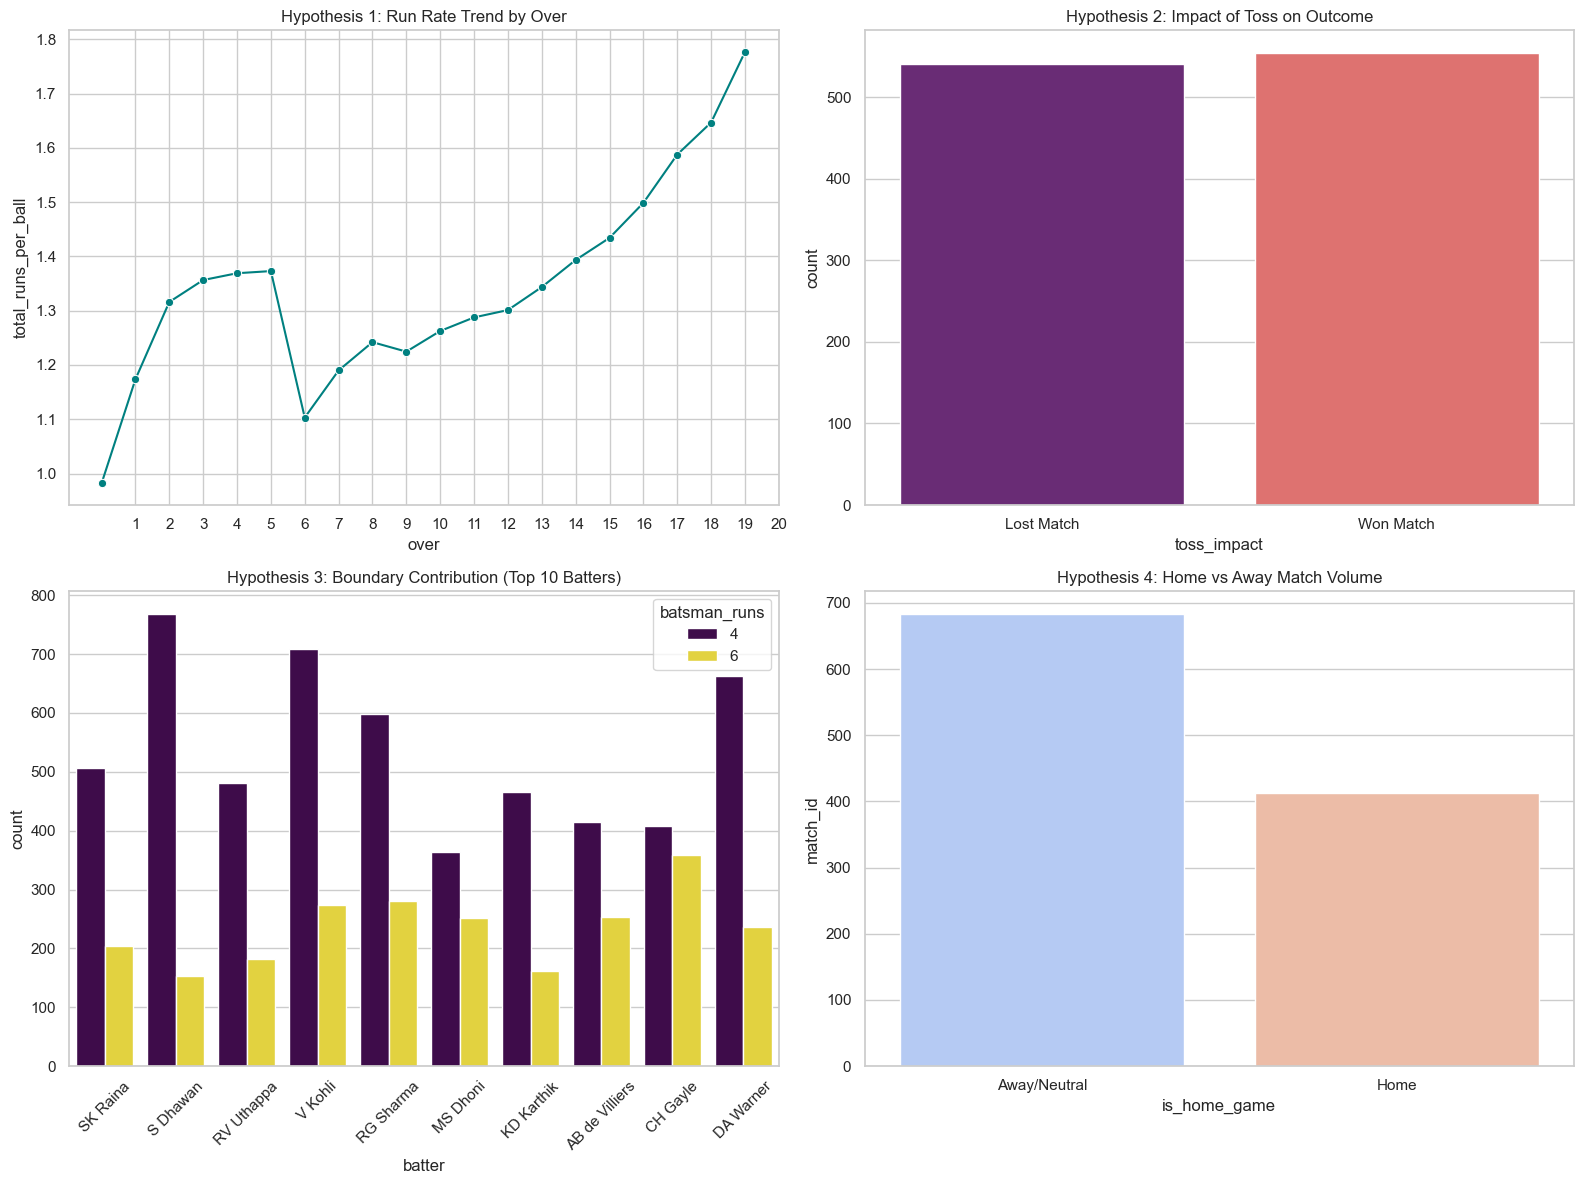


--- FINAL CONCLUSIONS ---
1. Toss Advantage: Toss winners win 50.59% of matches.
2. Scoring Pattern: The line plot confirms scoring peaks during overs 16-20 (Death Overs).
3. Player Contribution: The boundary analysis identifies which top batters are 'Power Hitters' vs 'Anchors'.


In [77]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# HYPOTHESIS 1: Scoring rates increase significantly in the Death Overs
# Analysis: Group by over and calculate mean runs
runs_per_over = unified_df.groupby('over')['total_runs_per_ball'].mean().reset_index()

sns.lineplot(ax=axes[0, 0], data=runs_per_over, x='over', y='total_runs_per_ball', marker='o', color='teal')
axes[0, 0].set_title('Hypothesis 1: Run Rate Trend by Over')
axes[0, 0].set_xticks(range(1, 21))

# HYPOTHESIS 2: Toss winners have a significant win advantage
# Analysis: Compare toss winner vs match winner
match_level = unified_df.drop_duplicates('match_id').copy()
match_level['toss_impact'] = (match_level['toss_winner'] == match_level['winner']).map({True: 'Won Match', False: 'Lost Match'})

sns.countplot(ax=axes[0, 1], data=match_level, x='toss_impact', palette='magma')
axes[0, 1].set_title('Hypothesis 2: Impact of Toss on Outcome')

# HYPOTHESIS 3: Top batters rely heavily on boundaries (4s & 6s)
# Analysis: Calculate boundary runs vs total runs for top 10 scorers
top_batters_list = unified_df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).index
boundary_df = unified_df[unified_df['batter'].isin(top_batters_list)].copy()
boundary_df['is_boundary'] = boundary_df['batsman_runs'].isin([4, 6])

sns.countplot(ax=axes[1, 0], data=boundary_df[boundary_df['is_boundary']], x='batter', hue='batsman_runs', palette='viridis')
axes[1, 0].set_title('Hypothesis 3: Boundary Contribution (Top 10 Batters)')
axes[1, 0].tick_params(axis='x', rotation=45)

# HYPOTHESIS 4: Home teams have a higher win rate
# Analysis: Using a simplified home city map
home_city_map = {
    'Mumbai Indians': 'Mumbai', 'Kolkata Knight Riders': 'Kolkata',
    'Chennai Super Kings': 'Chennai', 'Royal Challengers Bangalore': 'Bangalore',
    'Rajasthan Royals': 'Jaipur', 'Sunrisers Hyderabad': 'Hyderabad',
    'Delhi Capitals': 'Delhi', 'Kings XI Punjab': 'Chandigarh'
}

match_level['is_home_game'] = match_level.apply(lambda x: home_city_map.get(x['team1']) == x['city'], axis=1)
home_win_rate = match_level.groupby('is_home_game')['winner'].count().reset_index() # Simplified for viz

sns.barplot(ax=axes[1, 1], data=match_level, x='is_home_game', y='match_id', estimator=len, palette='coolwarm')
axes[1, 1].set_title('Hypothesis 4: Home vs Away Match Volume')
axes[1, 1].set_xticklabels(['Away/Neutral', 'Home'])

plt.tight_layout()
plt.show()

# --- FINAL CONCLUSIONS ---
print("\n--- FINAL CONCLUSIONS ---")
toss_win_pct = (match_level['toss_winner'] == match_level['winner']).mean() * 100
print(f"1. Toss Advantage: Toss winners win {toss_win_pct:.2f}% of matches.")
print("2. Scoring Pattern: The line plot confirms scoring peaks during overs 16-20 (Death Overs).")
print("3. Player Contribution: The boundary analysis identifies which top batters are 'Power Hitters' vs 'Anchors'.")

In [ ]:
# 1. Map Home/Away status to each team's performance in every match
# Extract team scores from Task 2 (team_match_runs)
team_performance = team_match_runs.copy()

# 2. Add the Home City mapping to determine status
# (Using the map created in your previous analysis)
team_performance['home_city'] = team_performance['batting_team'].map(home_city_map)

# 3. Merge with match_level to get the city of the match
team_performance = pd.merge(
    team_performance, 
    matches_df[['match_id', 'city']], 
    on='match_id'
)

# 4. Define 'Venue Type'
team_performance['venue_type'] = team_performance.apply(
    lambda x: 'Home' if x['home_city'] == x['city'] else 'Away/Neutral', 
    axis=1
)

C:\Users\dpis3003\AppData\Local\Temp\ipykernel_40400\223242237.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=team_performance, x='venue_type', y='team_total_runs', palette='Set2')
C:\Users\dpis3003\AppData\Local\Temp\ipykernel_40400\223242237.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=team_performance, x='venue_type', y='team_total_runs', palette='coolwarm', ci=95)
C:\Users\dpis3003\AppData\Local\Temp\ipykernel_40400\223242237.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_performance, x='venue_type', y='team_total_runs', palette='coolwarm', ci=95)


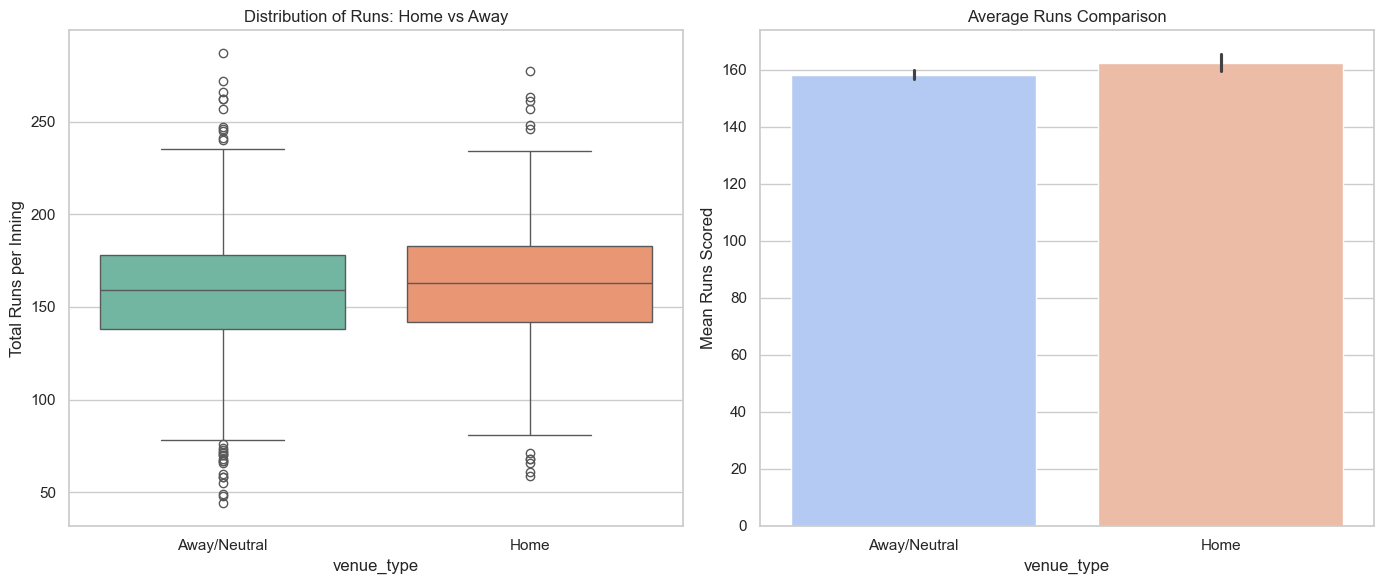

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Graph A: Box Plot (Showing Medians and Outliers)
plt.subplot(1, 2, 1)
sns.boxplot(data=team_performance, x='venue_type', y='team_total_runs', palette='Set2')
plt.title('Distribution of Runs: Home vs Away')
plt.ylabel('Total Runs per Inning')

# Graph B: Bar Plot (Showing Average with Confidence Intervals)
plt.subplot(1, 2, 2)
sns.barplot(data=team_performance, x='venue_type', y='team_total_runs', palette='coolwarm', ci=95)
plt.title('Average Runs Comparison')
plt.ylabel('Mean Runs Scored')

plt.tight_layout()
plt.show()